# **Data Understanding.**

In [1]:
# Load the cleaned dataset from Project 1 and preview the first 5 rows
import pandas as pd
df = pd.read_csv('cleaned_titanic1.csv')
#1
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# View the last 5 rows of the dataset
df.tail()


,PassengerId,Survived,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked
886,887,0,2,male,27.0,0,0,13.00,S
887,888,1,1,female,19.0,0,0,30.00,S
888,889,0,3,female,28.0,1,2,23.45,S
889,890,1,1,male,26.0,0,0,30.00,C
890,891,0,3,male,32.0,0,0,7.75,Q


In [3]:
# Check the size of the dataset (rows, columns)
df.shape

(891, 9)

In [4]:
# Check the current column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SiblingsSpouses',
       'ParentsChildren', 'Fare', 'Embarked'],
      dtype='object')

In [ ]:
# Reorder columns for readability: identifiers, personal details, family info, ticket info, then the target Survived last
df = df[['PassengerId', 'Pclass', 'Sex', 'Age', 'SiblingsSpouses', 'ParentsChildren', 'Fare', 'Embarked', 'Survived']]

In [6]:
# Confirm the new column order
df.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SiblingsSpouses',
       'ParentsChildren', 'Fare', 'Embarked', 'Survived'],
      dtype='object')

In [7]:
# Check column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Sex              891 non-null    object 
 3   Age              891 non-null    float64
 4   SiblingsSpouses  891 non-null    int64  
 5   ParentsChildren  891 non-null    int64  
 6   Fare             891 non-null    float64
 7   Embarked         891 non-null    object 
 8   Survived         891 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [8]:
# Get summary statistics for numeric columns
df.describe()

,PassengerId,Pclass,Age,SiblingsSpouses,ParentsChildren,Fare,Survived
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.361582,0.523008,0.381594,32.204208,0.383838
std,257.353842,0.836071,13.019697,1.102743,0.806057,49.693429,0.486592
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [9]:
# Check for missing values in each column
df.isnull().sum()

,0
PassengerId,0
Pclass,0
Sex,0
Age,0
SiblingsSpouses,0
ParentsChildren,0
Fare,0
Embarked,0
Survived,0


In [10]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

 **Explaination:**


 This dataset contains information about 891 passengers aboard the Titanic, describing personal details such as sex, age, and passenger class, along with family-related information like number of siblings or spouses and parents or children traveling together, as well as ticket fare, boarding port, and whether each passenger survived. The dataset has 9 columns in total, mixing numeric features like age, fare, and family counts with categorical features like sex, passenger class, and embarkation port. After the cleaning done in Project 1, there are no missing values or duplicate rows remaining, making this dataset fully ready for deeper analysis. Overall, this data allows us to explore how factors like class, gender, age, and family size may have influenced a passenger's chances of survival.

# **Feature Engineering.**

In [11]:
# Create FamilySize: total family members aboard including the passenger themselves
df['FamilySize'] = df['SiblingsSpouses'] + df['ParentsChildren'] + 1

In [12]:
# Confirm FamilySize column was added
df.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SiblingsSpouses',
       'ParentsChildren', 'Fare', 'Embarked', 'Survived', 'FamilySize'],
      dtype='object')

In [13]:
# Preview the dataframe with the new FamilySize column
df.head()

,PassengerId,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked,Survived,FamilySize
0,1,3,male,22.0,1,0,7.2500,S,0,2
1,2,1,female,38.0,1,0,71.2833,C,1,2
2,3,3,female,26.0,0,0,7.9250,S,1,1
3,4,1,female,35.0,1,0,53.1000,S,1,2
4,5,3,male,35.0,0,0,8.0500,S,0,1


In [15]:
# Create IsAlone: flags whether a passenger had a FamilySize of 1 (i.e. traveled alone)
import numpy as np
df['IsAlone'] = np.where(df['FamilySize'] == 1, 'Yes', 'No')

In [17]:
# Confirm IsAlone column was added
df.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SiblingsSpouses',
       'ParentsChildren', 'Fare', 'Embarked', 'Survived', 'FamilySize',
       'IsAlone'],
      dtype='object')

In [16]:
# Preview the dataframe with the new IsAlone column
df.head()

,PassengerId,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked,Survived,FamilySize,IsAlone
0,1,3,male,22.0,1,0,7.2500,S,0,2,No
1,2,1,female,38.0,1,0,71.2833,C,1,2,No
2,3,3,female,26.0,0,0,7.9250,S,1,1,Yes
3,4,1,female,35.0,1,0,53.1000,S,1,2,No
4,5,3,male,35.0,0,0,8.0500,S,0,1,Yes


In [17]:
# Create AgeGroup: bucket passengers into Child, Teenager, Adult, or Senior Citizen based on age
df['AgeGroup'] = pd.cut(df['Age'],
                          bins=[0, 12, 19, 60, 100],
                          labels=['Child', 'Teenager', 'Adult', 'Senior Citizen'])

In [18]:
# Preview the dataframe with the new AgeGroup column
df.head()

,PassengerId,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked,Survived,FamilySize,IsAlone,AgeGroup
0,1,3,male,22.0,1,0,7.2500,S,0,2,No,Adult
1,2,1,female,38.0,1,0,71.2833,C,1,2,No,Adult
2,3,3,female,26.0,0,0,7.9250,S,1,1,Yes,Adult
3,4,1,female,35.0,1,0,53.1000,S,1,2,No,Adult
4,5,3,male,35.0,0,0,8.0500,S,0,1,Yes,Adult


In [19]:
# Preview more rows to see a variety of age groups
df.head(10)

,PassengerId,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked,Survived,FamilySize,IsAlone,AgeGroup
0,1,3,male,22.0,1,0,7.2500,S,0,2,No,Adult
1,2,1,female,38.0,1,0,71.2833,C,1,2,No,Adult
2,3,3,female,26.0,0,0,7.9250,S,1,1,Yes,Adult
3,4,1,female,35.0,1,0,53.1000,S,1,2,No,Adult
4,5,3,male,35.0,0,0,8.0500,S,0,1,Yes,Adult
5,6,3,male,28.0,0,0,8.4583,Q,0,1,Yes,Adult
6,7,1,male,54.0,0,0,51.8625,S,0,1,Yes,Adult
7,8,3,male,2.0,3,1,21.0750,S,0,5,No,Child
8,9,3,female,27.0,0,2,11.1333,S,1,3,No,Adult
9,10,2,female,14.0,1,0,30.0708,C,1,2,No,Teenager


In [20]:
# Create FareCategory: bucket passengers into Low, Medium, or High fare groups
df['FareCatagory']=pd.cut(df['Fare'],
                          bins=[-1,25,100,600],
                          labels=['Low','Medium','High'])

In [21]:
# Preview the dataframe with the new FareCategory column
df.head(10)

,PassengerId,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked,Survived,FamilySize,IsAlone,AgeGroup,FareCatagory
0,1,3,male,22.0,1,0,7.2500,S,0,2,No,Adult,Low
1,2,1,female,38.0,1,0,71.2833,C,1,2,No,Adult,Medium
2,3,3,female,26.0,0,0,7.9250,S,1,1,Yes,Adult,Low
3,4,1,female,35.0,1,0,53.1000,S,1,2,No,Adult,Medium
4,5,3,male,35.0,0,0,8.0500,S,0,1,Yes,Adult,Low
5,6,3,male,28.0,0,0,8.4583,Q,0,1,Yes,Adult,Low
6,7,1,male,54.0,0,0,51.8625,S,0,1,Yes,Adult,Medium
7,8,3,male,2.0,3,1,21.0750,S,0,5,No,Child,Low
8,9,3,female,27.0,0,2,11.1333,S,1,3,No,Adult,Low
9,10,2,female,14.0,1,0,30.0708,C,1,2,No,Teenager,Medium


In [22]:
# Check the last rows to see the new features applied across the dataset
df.tail(10)

,PassengerId,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked,Survived,FamilySize,IsAlone,AgeGroup,FareCatagory
881,882,3,male,33.0,0,0,7.8958,S,0,1,Yes,Adult,Low
882,883,3,female,22.0,0,0,10.5167,S,0,1,Yes,Adult,Low
883,884,2,male,28.0,0,0,10.5000,S,0,1,Yes,Adult,Low
884,885,3,male,25.0,0,0,7.0500,S,0,1,Yes,Adult,Low
885,886,3,female,39.0,0,5,29.1250,Q,0,6,No,Adult,Medium
886,887,2,male,27.0,0,0,13.0000,S,0,1,Yes,Adult,Low
887,888,1,female,19.0,0,0,30.0000,S,1,1,Yes,Teenager,Medium
888,889,3,female,28.0,1,2,23.4500,S,0,4,No,Adult,Low
889,890,1,male,26.0,0,0,30.0000,C,1,1,Yes,Adult,Medium
890,891,3,male,32.0,0,0,7.7500,Q,0,1,Yes,Adult,Low


# **Explaination.**

**Family Size:**

This feature combines siblings, spouses, parents, and children into one number representing a passenger's total family size aboard, including themselves. It helps reveal whether traveling with a larger or smaller family group had any relationship with survival chances.


**Is Alone:**


This feature flags whether a passenger was traveling completely alone or with family. It simplifies Family Size into an easy yes/no comparison, useful for checking if solo travelers behaved differently in terms of survival compared to those with family present.

**Fare Category:**

This feature groups passengers into Low, Medium, or High fare categories based on how much they paid. Since fare often reflects a passenger's class and wealth, this helps reveal whether ticket price had any visible relationship with survival outcomes.


# **Exploratory Data Analysis.**



**Q1:What percentage of passengers survived?**

In [23]:
# Import visualization libraries for the EDA section
import matplotlib.pyplot as plt
import seaborn as sns

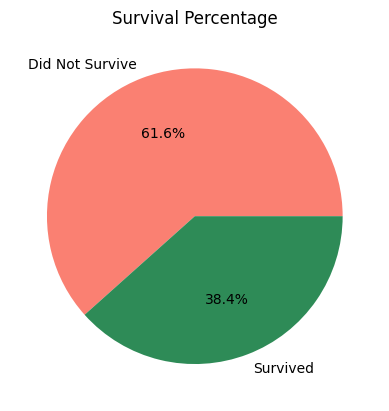

In [24]:
# Q1: Pie chart showing the percentage of passengers who survived vs. did not survive
survival_counts = df['Survived'].value_counts()
plt.pie(survival_counts, labels=['Did Not Survive', 'Survived'], autopct='%1.1f%%', colors=['salmon', 'seagreen'])
plt.title('Survival Percentage')
plt.show()

Only 38.4% of passengers survived, while the majority (61.6%) did not survive.

**Q2:Which gender had the highest survival rate?**

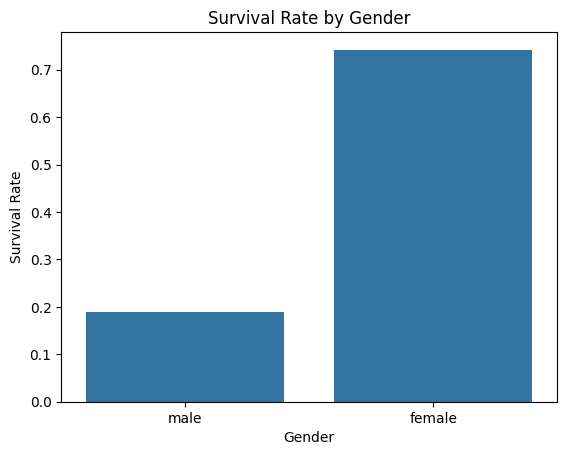

In [25]:
# Q2: Bar chart comparing survival rate between male and female passengers
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

Women had a dramatically higher survival rate than men — nearly four times higher. This lines up with the well-known historical "women and children first" evacuation policy during the Titanic disaster, where women were given priority access to lifeboats.

**Q3:Which passenger class had the highest survival rate?**

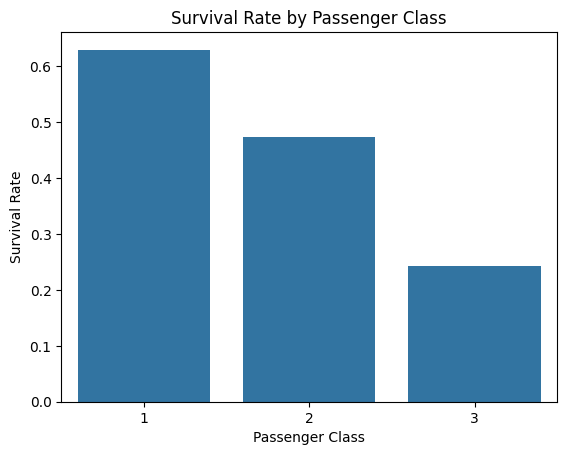

In [26]:
# Q3: Bar chart comparing survival rate across passenger classes
sns.barplot(x='Pclass', y='Survived',data=df, errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

First-class passengers had the highest survival rate, more than double that of third-class passengers. This suggests wealthier passengers, likely with cabins closer to the lifeboats and possibly given priority during evacuation, had a significantly better chance of survival than those in lower classes.

**Q4:Does age affect survival?**

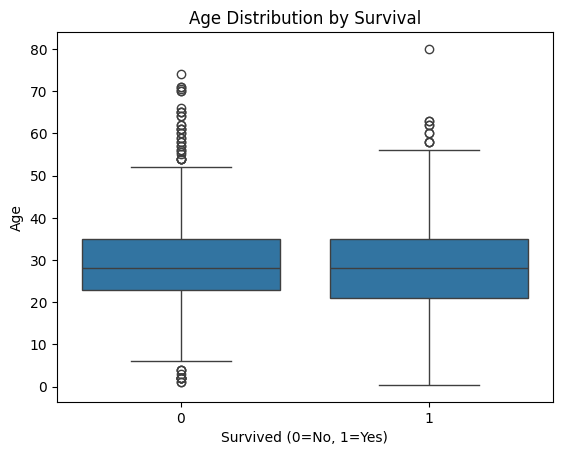

In [27]:
# Q4: Box plot comparing age distribution between survivors and non-survivors
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Age')
plt.show()

Unlike gender or class, age doesn't show a strong, obvious difference between survivors and non-survivors — the typical age range looks fairly similar for both groups. This suggests age alone wasn't as strong a factor in survival compared to gender or passenger class. That said, you might notice from the outlier dots at the top that a couple of very elderly passengers (around 70-80) still perished, which fits with age being a weaker, less decisive factor here compared to the sharper patterns you saw with Sex and Pclass.

**Q5:Does fare influence survival?**

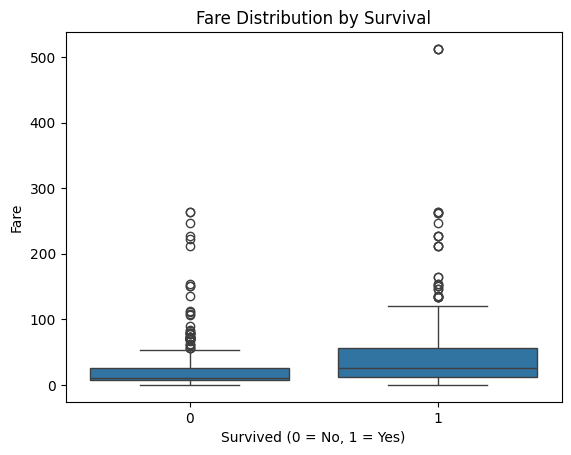

In [28]:
# Q5: Box plot comparing fare distribution between survivors and non-survivors
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

Passengers who survived tended to have paid higher fares on average compared to those who didn't survive. This makes sense alongside what we already found with passenger class — since fare and class are closely linked, wealthier passengers who paid more likely traveled in first or second class, giving them a survival advantage.

**Q6:Did passengers travelling alone survive more often?**

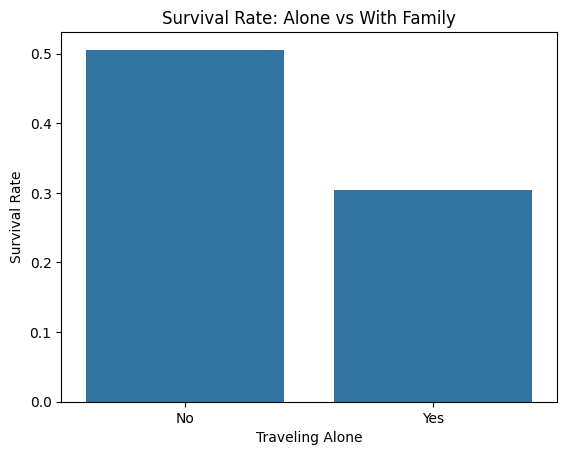

In [29]:
# Q6: Bar chart comparing survival rate for passengers traveling alone vs. with family
sns.barplot(x='IsAlone', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate: Alone vs With Family')
plt.xlabel('Traveling Alone')
plt.ylabel('Survival Rate')
plt.show()

Passengers traveling with family had a notably higher survival rate than those traveling alone — roughly 50% versus 30%. This might reflect that families helped each other during evacuation, or that solo travelers were disproportionately male (since we saw earlier men had far lower survival rates), which could be part of what's driving this pattern rather than being alone itself.

**Q7:Which embarkation port had the highest survival rate?**

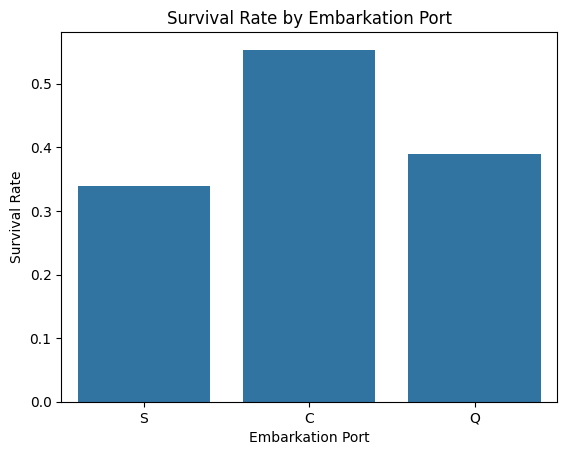

In [30]:
# Q7: Bar chart comparing survival rate across embarkation ports
sns.barplot(x='Embarked', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

Passengers who boarded at port Cherbourg had the highest survival rate, notably higher than those who boarded at Southampton or Queenstown.This is likely connected to passenger class rather than the port itself Cherbourg is known to have had a higher proportion of first-class passengers boarding there, which ties back to what you already found in Question 3 about class strongly affecting survival.

**Q8:What is the relationship between passenger class and fare?**

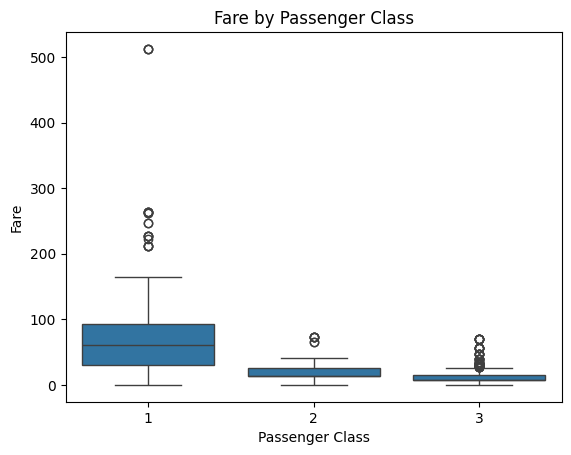

In [31]:
# Q8: Box plot showing how fare varies across passenger classes
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

Fare drops sharply as passenger class number increases first class passengers paid substantially more than second or third class, with a clear, consistent step down between each class. This confirms fare is essentially a direct reflection of passenger class, which explains why earlier we saw both fare and class independently linked to survival they're really capturing overlapping information about a passenger's wealth and status.

**Q9:Correlation Heatmap.**

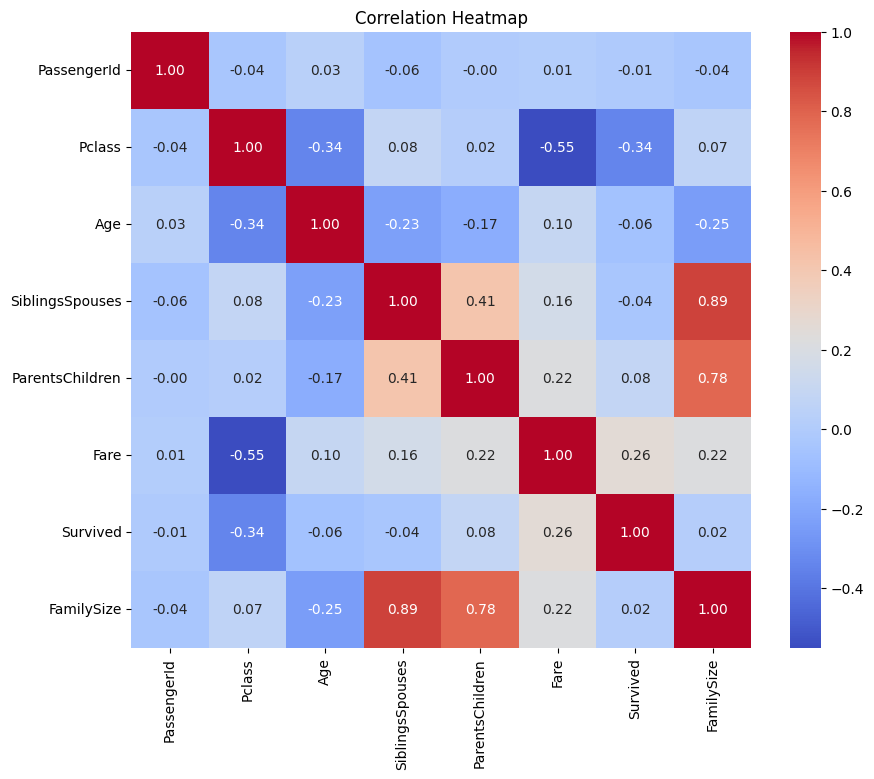

In [32]:
# Q9: Correlation heatmap showing relationships between all numeric columns
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Strongest positive correlation:**

SiblingsSpouses and FamilySize at 0.89. This makes sense mathematically rather than being a deep insight — remember, FamilySize was literally built by adding SiblingsSpouses and ParentsChildren together, so of course they move closely together. ParentsChildren and FamilySize at 0.78 shows the same expected relationship.

**Strongest negative correlation:**

 Pclass and Fare at -0.55. This confirms what you already saw visually in Question 8 — as passenger class number goes up (meaning a lower/cheaper class), fare goes down. This is a real, meaningful relationship, not just a byproduct of how a feature was built.


**Other interesting observations:**

Pclass and Survived shows -0.34  since class numbers increase for cheaper/lower classes, this negative number actually confirms that lower class was linked to lower survival, matching Question 3's finding. Fare and Survived shows a positive 0.26, which lines up with Question 5's finding that survivors tended to pay more. Age and Pclass shows -0.34, suggesting younger passengers were slightly more common in higher (cheaper) class numbers, or older passengers tended toward first class.

**Q10:your own additional analysis**

**Fare Category vs Survived:**

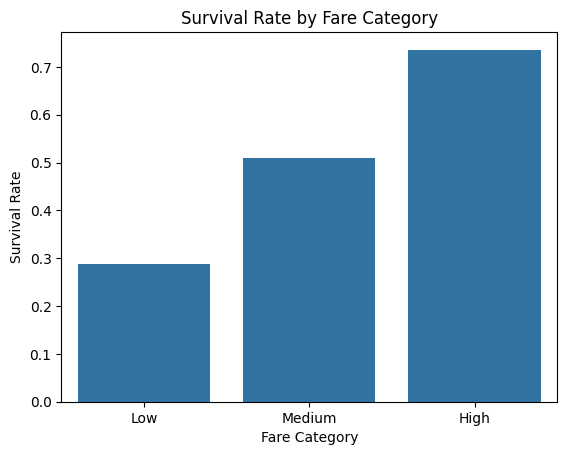

In [33]:
# Q10: Own analysis - bar chart comparing survival rate across fare categories
sns.barplot(x='FareCatagory', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate by Fare Category')
plt.xlabel('Fare Category')
plt.ylabel('Survival Rate')
plt.show()

I think there is nothing left so I choose this one and here Survival rate increases steadily and clearly as fare category rises from Low to Medium to High, high-fare passengers were more than twice as likely to survive compared to low-fare passengers. This reinforces everything found earlier in the project.
fare, class, and survival are all closely connected, likely reflecting that wealthier passengers had better access to lifeboats and safer areas of the ship during the evacuation.

# **Statistical Analysis.**

>



In [34]:
# Confirm available columns before statistical analysis
df.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SiblingsSpouses',
       'ParentsChildren', 'Fare', 'Embarked', 'Survived', 'FamilySize',
       'IsAlone', 'AgeGroup', 'FareCatagory'],
      dtype='object')

In [35]:
# Preview the dataframe before calculating statistics
df.head(10)

,PassengerId,Pclass,Sex,Age,SiblingsSpouses,ParentsChildren,Fare,Embarked,Survived,FamilySize,IsAlone,AgeGroup,FareCatagory
0,1,3,male,22.0,1,0,7.2500,S,0,2,No,Adult,Low
1,2,1,female,38.0,1,0,71.2833,C,1,2,No,Adult,Medium
2,3,3,female,26.0,0,0,7.9250,S,1,1,Yes,Adult,Low
3,4,1,female,35.0,1,0,53.1000,S,1,2,No,Adult,Medium
4,5,3,male,35.0,0,0,8.0500,S,0,1,Yes,Adult,Low
5,6,3,male,28.0,0,0,8.4583,Q,0,1,Yes,Adult,Low
6,7,1,male,54.0,0,0,51.8625,S,0,1,Yes,Adult,Medium
7,8,3,male,2.0,3,1,21.0750,S,0,5,No,Child,Low
8,9,3,female,27.0,0,2,11.1333,S,1,3,No,Adult,Low
9,10,2,female,14.0,1,0,30.0708,C,1,2,No,Teenager,Medium


In [36]:
# Calculate mean, median, mode, and standard deviation for Age, Fare, and FamilySize
for colm in ['Age','Fare','FamilySize']:
  print(f"for {colm}:")
  print("Mean:",round(df[colm].mean(),3))
  print("Median:",round(df[colm].median(),3))
  print("Mode:",round(df[colm].mode()[0],3))
  print("Standard Deviation:",round(df[colm].std(),3))
  print()

for Age:
Mean: 29.362
Median: 28.0
Mode: 28.0
Standard Deviation: 13.02

for Fare:
Mean: 32.204
Median: 14.454
Mode: 8.05
Standard Deviation: 49.693

for FamilySize:
Mean: 1.905
Median: 1.0
Mode: 1
Standard Deviation: 1.613



**Age:** Mean and median are close 29 and 28 so ages are pretty balanced, not skewed. Most people were roughly between mid-teens and early 40s.

**Fare:** Mean 32 is way higher than median 14 a few expensive first-class tickets are dragging the average up, while most people actually paid much less. This is why we used median.

**FamilySize:** Mean 1.9, median 1, and mode 1 all point the same way most people traveled either alone or with just one person. A few bigger families pull the average up slightly, but small families were clearly the norm.

# **Dashboard.**

## Survival Distribution:

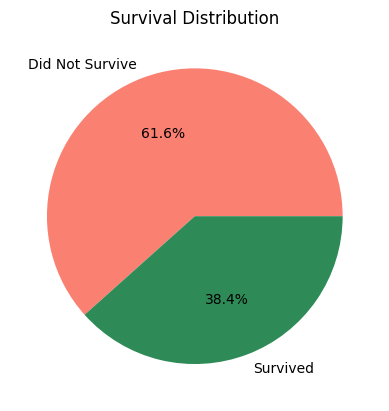

In [37]:
# Dashboard - Survival Distribution (reused from Q1)
survival_counts = df['Survived'].value_counts()
plt.pie(survival_counts, labels=['Did Not Survive', 'Survived'], autopct='%1.1f%%', colors=['salmon', 'seagreen'])
plt.title('Survival Distribution')
plt.show()

# Gender Distribution:

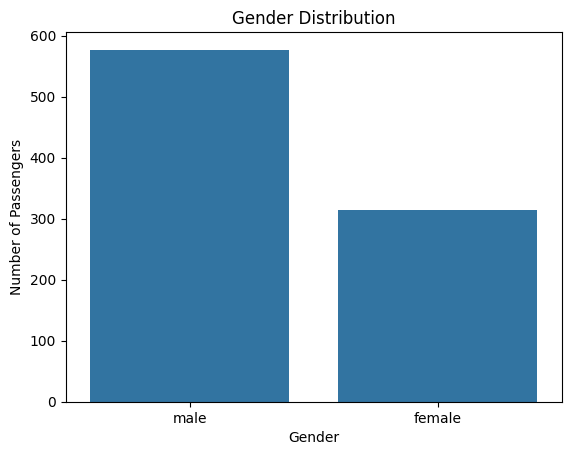

In [38]:
# Dashboard - Gender Distribution (simple count, not linked to survival)
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

# Passenger Class Distribution:

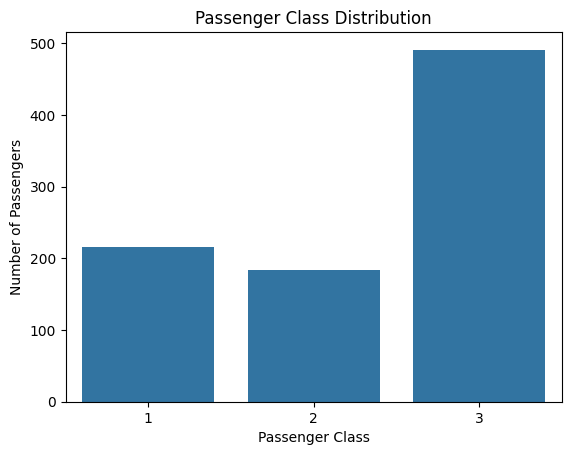

In [39]:
# Dashboard - Passenger Class Distribution (simple count, not linked to survival)
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

# Age Distribution:

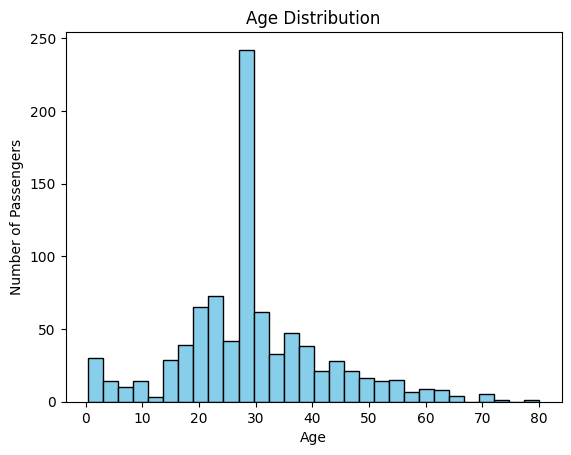

In [40]:
# Dashboard - Age Distribution (histogram of all passenger ages)
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

# Fare Distribution:

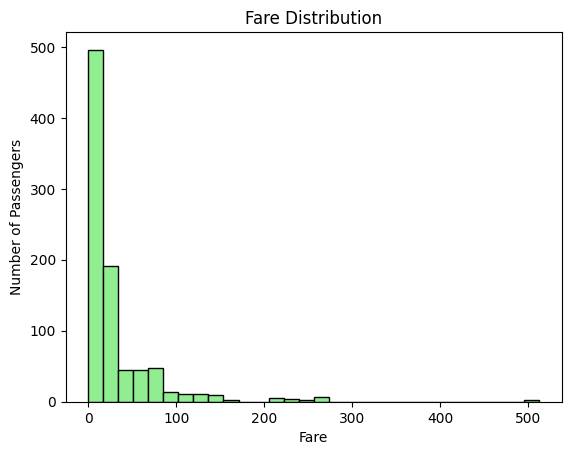

In [41]:
# Dashboard - Fare Distribution (histogram of all passenger fares)
plt.hist(df['Fare'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.show()

# Correlation Heatmap:

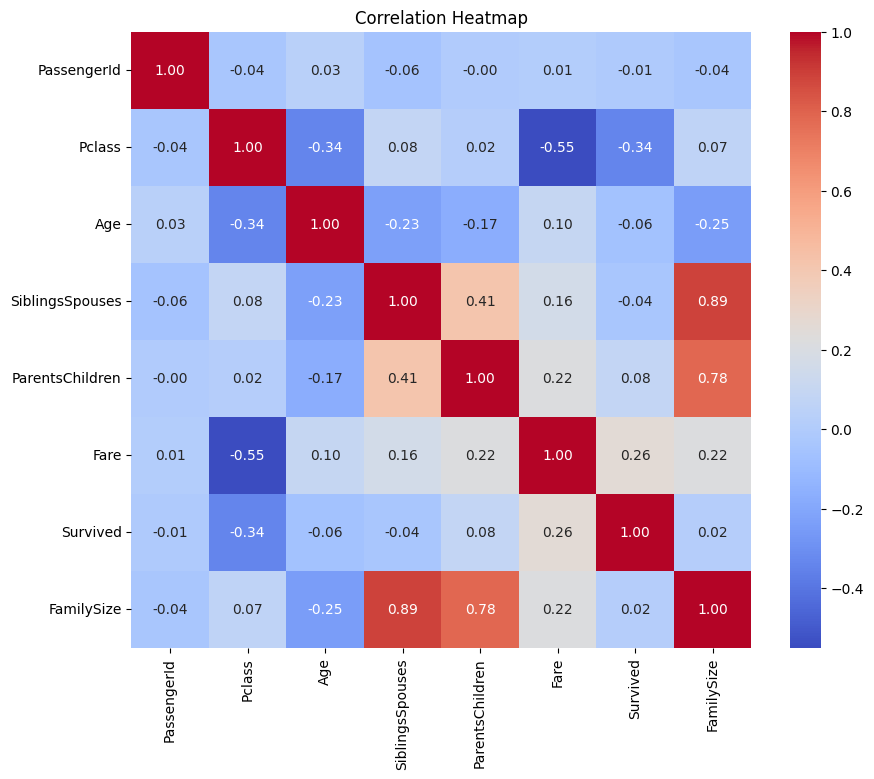

In [42]:
# Dashboard - Correlation Heatmap (reused from Q9)
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# **Business Insights.**

**1.**
Only 38.4% of passengers survived, meaning the majority of people aboard did not survive the disaster.

**2.**
Gender was one of the strongest survival factors women survived at roughly 74%, compared to only about 19% for men.

**3.**
Passenger class had a major effect on survival first-class passengers survived at 63%, compared to just 24% for third-class passengers.

**4.**
Age alone did not show a strong link to survival the typical age range for survivors and non-survivors was very similar.

**5.**
Fare was closely tied to survival passengers who paid higher fares were noticeably more likely to survive than those who paid less.

**6.**
Passengers traveling with family had a higher survival rate about 50% compared to those traveling alone about 30%.

**7.**
Passengers who boarded at Cherbourg had the highest survival rate among all embarkation points, likely linked to a higher share of first-class passengers boarding there.

**8.**
Fare and passenger class were strongly related — first-class fares were dramatically higher than second or third class, confirming fare largely reflects class status.

**9.**
When grouped into Fare Categories, survival rate rose steadily from Low to Medium to High fare groups, reinforcing that wealth and ticket price played a real role in survival chances.

**10.**
Family size was generally small most passengers traveled alone or with just one other person, and very large families were rare exceptions rather than the norm.


# **Business Recommendations.**

**1.**
Improve evacuation access for lower-class passengers third-class survival 24% was far below first-class 63%, so lifeboat access shouldn't be concentrated near premium cabins.

**2.**
Strengthen family-assistance during emergencies passengers with family survived more 50% than solo travelers 30%, so staff should help families stay together and move quickly.

**3.**
Rethink cabin placement near safety exits — since cheaper cabins were likely farther from lifeboats, layout should prioritize equal access to safety, not just proximity for premium cabins.

**4.**
Standardize safety briefings for all passengers — men survived at just 19% vs 74% for women, showing the need for clear, universal safety protocols for everyone, not just certain groups.

**5.**
Standardize lifeboat readiness across boarding points — survival varied by embarkation port, suggesting uneven safety preparedness that should be made consistent ship-wide.